In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ydata_profiling

In [49]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

In [3]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Data Transformation

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [7]:
df.isna().sum()[df.isna().sum() > 0]

TotalCharges    11
dtype: int64

### EDA

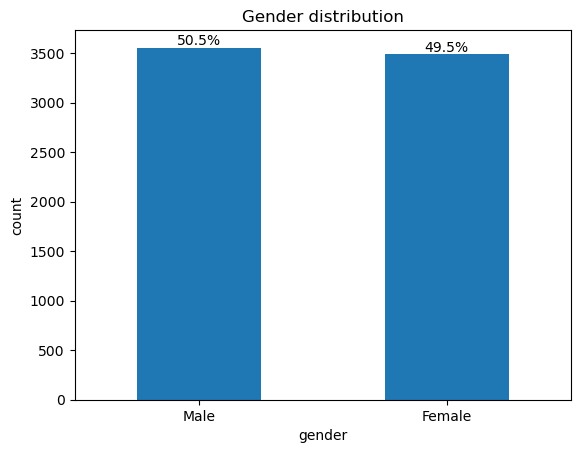

In [8]:
ax = df['gender'].value_counts().plot(kind='bar')

# axis labels
plt.xlabel('gender')
plt.ylabel('count')
plt.title('Gender distribution')
plt.xticks(rotation=0)

# total for percentage calculation
total = len(df)

# add % labels on top of bars
for p in ax.patches:
    count = int(p.get_height())
    percentage = f'{(count/total)*100:.1f}%'
    
    ax.annotate(percentage,
                (p.get_x() + p.get_width() / 2, count),
                ha='center', va='bottom')

plt.show()


# Gender distribution is almost equal in dataset.

<Axes: xlabel='Dependents', ylabel='count'>

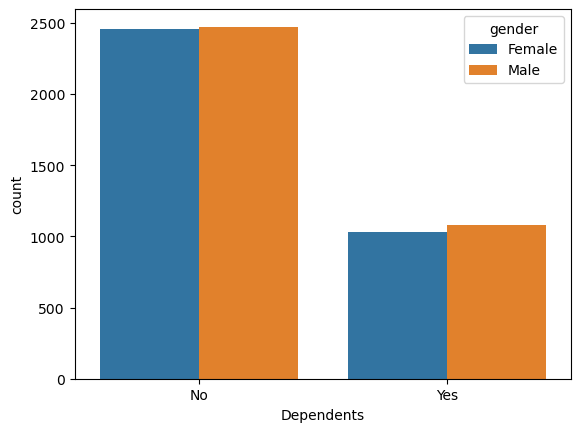

In [9]:
ax2 = (
    df['Dependents'].groupby(df['gender']).value_counts().reset_index(name='count')
)
sns.barplot(data=ax2, x='Dependents', y='count', hue='gender')

# Dependents distribution is not correlated with gender.

Partner,No,Yes
Dependents,,
No,90.085141,48.589065
Yes,9.914859,51.410935


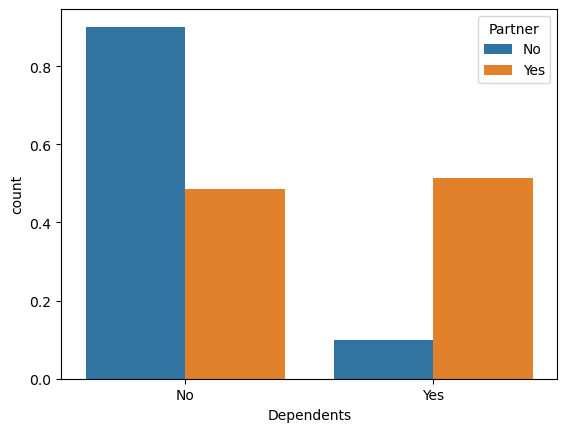

In [10]:
ax3 = (
    df['Dependents'].groupby(df['Partner']).value_counts(normalize=True).reset_index(name='count')
)

sns.barplot(data=ax3, x='Dependents', y='count', hue='Partner')
pd.crosstab(df['Dependents'], df['Partner'],  normalize = 'columns')*100

# 10% of customers have No partner but they are dependent.
# Customers with Partner have equal distribution of dependents and non-dependents.
# We cannot drop any of these columns as they are not highly correlated.

In [11]:
# Ydata profiling report for extensive EDA.

report= ydata_profiling.ProfileReport(df)
report.to_file('Telco_customer_report2.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 21/21 [00:00<00:00, 42.05it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [12]:
#  High correlation between MultipleLines and PhoneService
df['MultipleLines'].groupby(df['PhoneService']).value_counts(normalize=True).reset_index(name='percentage')

# We can drop PhoneService.
# as we can see if MultipleLines is Yes or No then PhoneService is Yes only.

df.drop('PhoneService',axis=1,inplace=True)


In [13]:
pd.crosstab(df['InternetService'], df['OnlineBackup'])
pd.crosstab(df['OnlineSecurity'], df['OnlineBackup'])

# No correlation between InternetService vs OnlineBackup and OnlineSecurity vs OnlineBackup.

OnlineBackup,No,No internet service,Yes
OnlineSecurity,,,
No,2195,0,1303
No internet service,0,1526,0
Yes,893,0,1126


In [14]:
df.groupby('InternetService')['MonthlyCharges'].mean().reset_index()

# Fiber optic is too expensive than DSL.

,InternetService,MonthlyCharges
0,DSL,58.102169
1,Fiber optic,91.500129
2,No,21.079194


In [15]:
# Shares of different InternetService
(df['InternetService'].value_counts(normalize=True)*100).reset_index()

# 44% of market has been captured by Fiber optic and 34% by DSL.
# But huge percentage of customers (22%) have no internet service. So we can target those customers for better marketing strategy.

,InternetService,proportion
0,Fiber optic,43.958540
1,DSL,34.374556
2,No,21.666903


In [16]:
df.groupby('InternetService')['tenure'].value_counts().reset_index().head(20)


,InternetService,tenure,count
0,DSL,1,212
1,DSL,72,133
2,DSL,2,82
3,DSL,3,71
4,DSL,71,62
5,DSL,4,61
6,DSL,70,52
7,DSL,7,46
8,DSL,5,43
9,DSL,8,43


In [17]:
df['Churn'].value_counts(normalize=True)*100

# In given data, Churn rate of customers is 26.5% which is quite high. 

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

#### Churn EDA 

,Churn,count
0,No,5174
1,Yes,1869


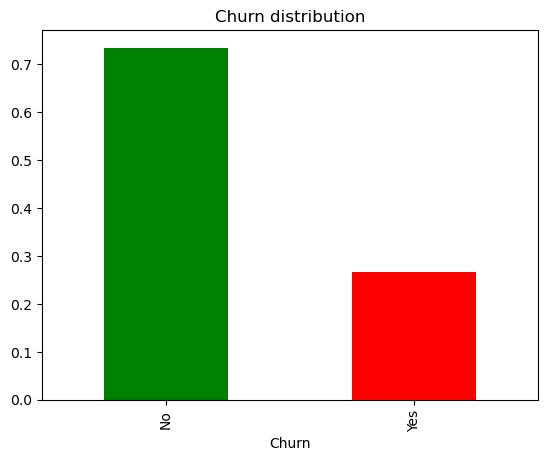

In [18]:
df['Churn'].value_counts(normalize=True).plot(kind='bar', color=['green', 'red'], title='Churn distribution')
df['Churn'].value_counts().reset_index(name='count')

# There are 73.5% customers who continue there services. Overall churn rate is 26.5%.

Contract,Month-to-month,One year,Two year
Churn,,,
No,0.572903,0.887305,0.971681
Yes,0.427097,0.112695,0.028319


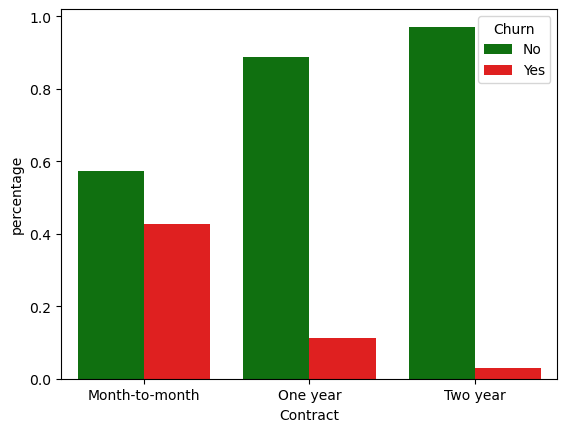

In [19]:
ax4 = df.groupby('Contract')['Churn'].value_counts(normalize=True).reset_index(name='percentage')
sns.barplot(data=ax4,
            x = 'Contract',
            y = 'percentage',
            hue = 'Churn',
            palette=['green', 'red']
            )
pd.crosstab(df['Churn'], df['Contract'],normalize='columns')


# As contract period increases, churn rate decreases. 
# Customers with month-to-month contract have highest churn rate (43%) and customers with two year contract have lowest churn rate (9%).

InternetService,DSL,Fiber optic,No
Churn,,,
No,81.040892,58.107235,92.59502
Yes,18.959108,41.892765,7.40498


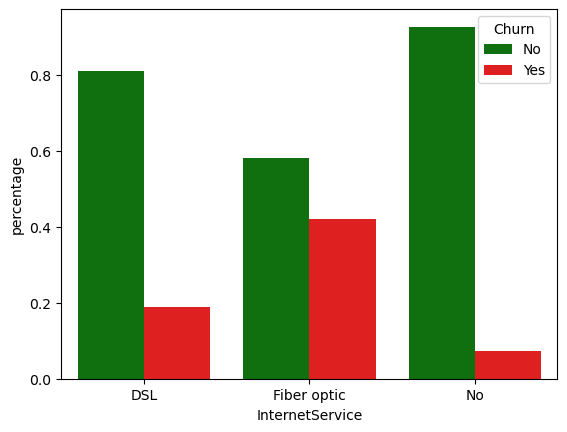

In [20]:
ax5 = df.groupby('InternetService')['Churn'].value_counts(normalize=True).reset_index(name='percentage')

sns.barplot(data=ax5,
            x='InternetService',
            y='percentage',
            errorbar=None,
            hue='Churn',
            palette=['green', 'red']
            )

pd.crosstab(df['Churn'], df['InternetService'], normalize='columns')*100
# ax5

# Customers with Fiber optic have the highest churn rate (42%)
# DSL customer have higher loyalty (81%) than Fiber optic (58%).

<Axes: xlabel='Churn', ylabel='tenure'>

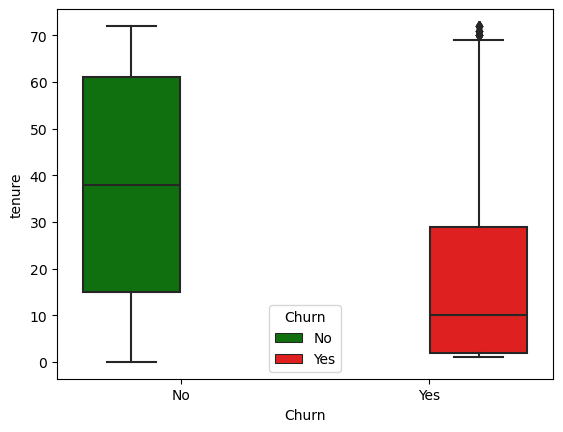

In [21]:
ax6 = df[['tenure', 'Churn']]
sns.boxplot(data=ax6,
                x='Churn',
                y='tenure',
                hue='Churn',
                palette=['green', 'red']
                )

# Higher tenures have high loyalty rate.
# There are some outliers in tenure column for customers who have churned. 

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

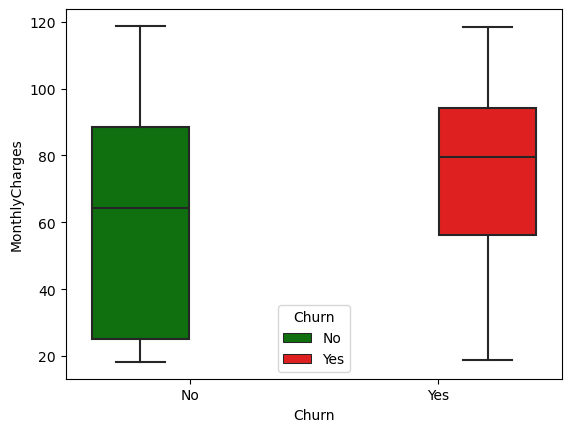

In [22]:
ax7 = df[['MonthlyCharges', 'Churn']]
sns.boxplot(data=ax7,
                x='Churn',
                y='MonthlyCharges',
                hue='Churn',
                palette=['green', 'red']
                )

# High monthly charges have high churn rate. So we can target those customers with better offers and discounts to reduce churn rate.

<Axes: xlabel='Churn', ylabel='TotalCharges'>

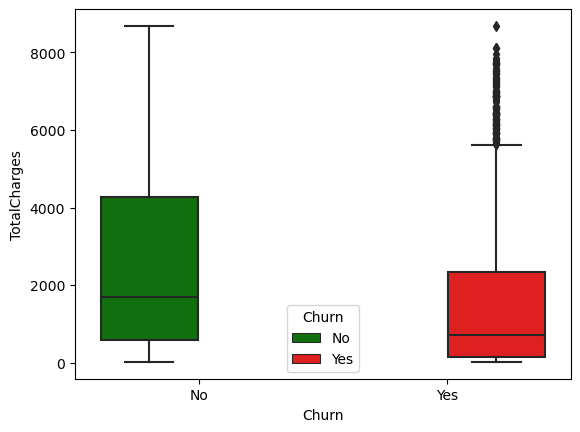

In [23]:
ax8 = df[['TotalCharges', 'Churn']]
sns.boxplot(data=ax8,
                x='Churn',
                y='TotalCharges',
                hue='Churn',
                palette=['green', 'red']
                )
# High total charges have high churn rate. 

PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Churn,,,,
No,83.290155,84.756899,54.714588,80.8933
Yes,16.709845,15.243101,45.285412,19.1067


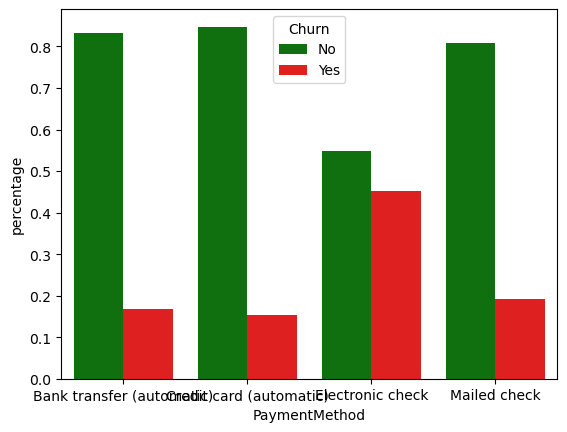

In [24]:
ax8 = df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).reset_index(name='percentage')

sns.barplot(data=ax8,
            x='PaymentMethod',
            y='percentage',
            hue='Churn',
            palette=['green', 'red'],
            
            )

pd.crosstab(df['Churn'], df['PaymentMethod'], normalize='columns')*100

# Customers with Electronic check payment method have the highest churn rate (35%) and customers with Credit card payment method have the lowest churn rate (20%).

#### Feature Engineering

In [25]:
df['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [26]:
# Label Encoding for categorical columns.

df['gender']= df['gender'].map({'Male':1, 'Female':0}).astype(int)
df['Partner']= df['Partner'].map({'Yes':1, 'No':0}).astype(int)
df['Dependents']= df['Dependents'].map({'Yes':1, 'No':0}).astype(int)
df['MultipleLines']= df['MultipleLines'].map({'Yes':1, 'No':0}).fillna(-1).astype(int)
df['OnlineSecurity']= df['OnlineSecurity'].map({'Yes':1, 'No':0}).fillna(-1).astype(int)
df['OnlineBackup']= df['OnlineBackup'].map({'Yes':1, 'No':0}).fillna(-1).astype(int)
df['DeviceProtection']= df['DeviceProtection'].map({'Yes':1, 'No':0}).fillna(-1).astype(int)
df['TechSupport']= df['TechSupport'].map({'Yes':1, 'No':0}).fillna(-1).astype(int)
df['StreamingTV']= df['StreamingTV'].map({'Yes':1, 'No':0}).fillna(-1).astype(int)
df['StreamingMovies']= df['StreamingMovies'].map({'Yes':1, 'No':0}).fillna(-1).astype(int)
df['Contract']= df['Contract'].map({'Two year':2, 'One year':1}).fillna(0).astype(int)
df['InternetService']= df['InternetService'].map({'Fiber optic':2, 'DSL':1}).fillna(0).astype(int)
df['PaperlessBilling'] = df['PaperlessBilling'].map({'Yes':1, 'No':0}).astype(int)
df['PaymentMethod']= df['PaymentMethod'].map({'Electronic check':3, 'Mailed check':2, 'Bank transfer (automatic)':1}).fillna(0).astype(int)
df['Churn']= df['Churn'].map({'Yes':1, 'No':0}).astype(int)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   int32  
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   int32  
 4   Dependents        7043 non-null   int32  
 5   tenure            7043 non-null   int64  
 6   MultipleLines     7043 non-null   int32  
 7   InternetService   7043 non-null   int32  
 8   OnlineSecurity    7043 non-null   int32  
 9   OnlineBackup      7043 non-null   int32  
 10  DeviceProtection  7043 non-null   int32  
 11  TechSupport       7043 non-null   int32  
 12  StreamingTV       7043 non-null   int32  
 13  StreamingMovies   7043 non-null   int32  
 14  Contract          7043 non-null   int32  
 15  PaperlessBilling  7043 non-null   int32  
 16  PaymentMethod     7043 non-null   int32  


### Fill NA values

<Axes: ylabel='Density'>

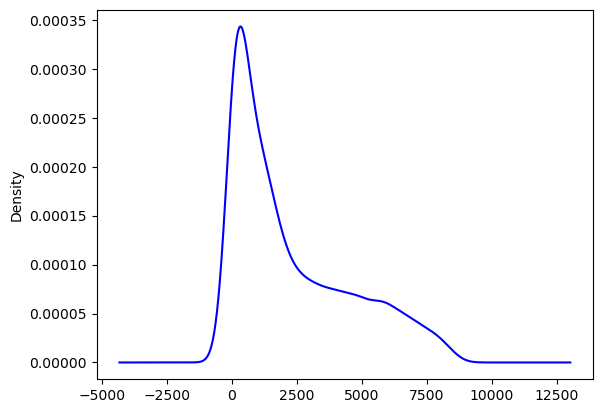

In [28]:
df['TotalCharges'].plot(kind='kde', color='blue', label='TotalCharges')
# (df['TotalCharges']-df['MonthlyCharges']*df['tenure']).plot(kind='kde', color='orange', label='Difference')


# TotalCharge graph is almost normally distributed. So we can impute missing values with mean or median.
# Else there are only 11 values missing. We can remove those rows as well.

<Axes: ylabel='Density'>

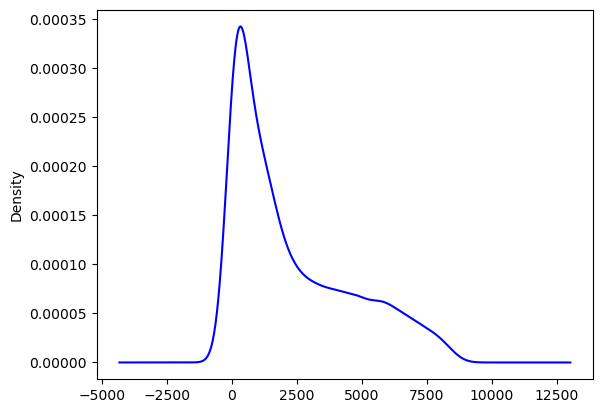

In [29]:
df['TotalCharges'].fillna(df['TotalCharges'].mean(), inplace=True)
df['TotalCharges'].plot(kind='kde', color='blue', label='TotalCharges')

In [31]:
df['tenure_group'] = pd.cut(df['tenure'], bins=[0,2,10,25,45,65,75])

In [32]:
df.drop('customerID', axis=1, inplace=True)

#### Train test split and transform

In [37]:
x= df.drop(['Churn'], axis=1)
y= df['Churn']

In [39]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [55]:
x_train.shape
y_train

2142    0
1623    0
6074    1
1362    1
6754    0
       ..
3772    1
5191    0
5226    0
5390    1
860     0
Name: Churn, Length: 5634, dtype: int32

In [54]:
lr = LogisticRegression()
lr.fit(x_train, y_train)
# y_pred = lr.predict(x_test)

TypeError: float() argument must be a string or a real number, not 'pandas._libs.interval.Interval'